In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import sys
import os

# ../bin/AnalysisVSPAERO.py をモジュールとしてインポート
sys.path.append(os.path.join('../../../')) # 親ディレクトリをモジュール探索パスに追加
from src.VvGammaChart import (
    calculate_stab_basic_metrics,
    collect_vv_wtip_sweep_progress,
    plot_vv_gamma_contour_panel,
    postprocess_vv_gamma_cases,
    run_vv_wtip_stability_sweep,
)

In [2]:
base_vsp3_path = Path('../../models/BRGlider/BRGlider.0G.vsp3')
output_dir = Path('')

vv_values = np.linspace(0.001, 0.006, 11)
tip_deflections = np.linspace(0.0, 2.0, 11)

# Set these to sequences such as np.linspace(...) when fixed axis ticks are desired.
VV_TICKS = np.linspace(0.001,0.006,6)
GAMMA_TICKS = np.linspace(0,8,9)

GRID_SIZE = 256
LEVELS = 256
METHOD = "linear"
FALLBACK_METHOD = "nearest"
SHOW_POINTS = False


COLORBAR_TICKS_BY_COLUMN = {
    # Column-name keyed examples:
    # "simple_turn_rate": np.linspace(-0.05, 0.05, 11),
    # "turn_trim_delta_r": np.linspace(-0.3, 0.3, 7),
    # "turn_trim_delta_r_per_beta": np.linspace(-20.0, 5.0, 6),
    # "sixdof_roll_response_phi_rate_per_delta_r": np.linspace(-0.06,0.0,7),
    # 'simple_turn_rate': np.linspace(-0.06,0.00,7),
    # "spiral_margin": np.linspace(-0.006,0.006,7),
}

PANEL_KWARGS = dict(
    grid_size=GRID_SIZE,
    levels=LEVELS,
    method=METHOD,
    fallback_method=FALLBACK_METHOD,
    colorbar_ticks_by_column=COLORBAR_TICKS_BY_COLUMN,
    x_ticks=VV_TICKS,
    y_ticks=GAMMA_TICKS,
    show_points=SHOW_POINTS,
    show_colorbar=True,
)


In [3]:
sweep = collect_vv_wtip_sweep_progress(
    vv_values,
    tip_deflections,
    output_dir,
    gamma_semispan=13.5,
    include_incomplete_cases=False,
    output_csv_path=output_dir / 'vv_wtip_stability_sweep_progress.csv',
)
sweep.head()


,case,case_index,case_count,Vv,tip_deflection,case_dir,gamma_semispan,vsp3_path,deflection_csv_path,stab_path,passed,vspaero_passed,error
0,vv_0p00100_wtip_0p00000,1,121,0.001,0.0,vv_0p00100_wtip_0p00000,13.5,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,True,True,
1,vv_0p00100_wtip_0p20000,2,121,0.001,0.2,vv_0p00100_wtip_0p20000,13.5,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,True,True,
2,vv_0p00100_wtip_0p40000,3,121,0.001,0.4,vv_0p00100_wtip_0p40000,13.5,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,True,True,
3,vv_0p00100_wtip_0p60000,4,121,0.001,0.6,vv_0p00100_wtip_0p60000,13.5,vv_0p00100_wtip_0p60000\vv_0p00100_wtip_0p6000...,vv_0p00100_wtip_0p60000\vv_0p00100_wtip_0p6000...,vv_0p00100_wtip_0p60000\vv_0p00100_wtip_0p6000...,True,True,
4,vv_0p00100_wtip_0p80000,5,121,0.001,0.8,vv_0p00100_wtip_0p80000,13.5,vv_0p00100_wtip_0p80000\vv_0p00100_wtip_0p8000...,vv_0p00100_wtip_0p80000\vv_0p00100_wtip_0p8000...,vv_0p00100_wtip_0p80000\vv_0p00100_wtip_0p8000...,True,True,


## 0. パラメータ計算

In [4]:

repo_root = Path(r"C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP")
notebook_root = repo_root / "examples" / "notebooks" / "vv_gamma_chart"

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.VvGammaChart import postprocess_vv_gamma_cases

# 入力CSV
# 通常は run_vv_wtip_stability_sweep() の出力を使う。
# 収束確認後に収束ケースだけに絞ったCSVを作った場合は、そちらを使う。
input_csv = notebook_root / "vv_wtip_stability_sweep_progress.csv"

output_csv = notebook_root / "vv_gamma_metrics_all_in.csv"
history_output_dir = notebook_root / "6dof_history_all_in"

print("input_csv :", input_csv)
print("output_csv:", output_csv)
print("history  :", history_output_dir)

# ============================================================
# 2. 機体条件
# ============================================================
# 単位系は .stab と必ず合わせる。
# .stab が SI 系なら、mass[kg], inertia[kg m^2], Uds[m/s], H[m]。

mass = 100.0
inertia = {
    'Ixx': 1000.0,
    'Iyy': 75.0,
    'Izz': 1000.0,
    'Ixz': 0.0,
}

# ============================================================
# 3. ラダー横転性能の評価条件
# ============================================================

delta_r = math.radians(-10.0)
target_delta_phi = math.radians(+2.0)

t_final = 10.0
max_step = 0.01

# 初期トリム・簡易ピッチ保持
delta_a = 0.0
delta_e = None
trim_elevator = True

theta_hold = True
theta_hold_kp = 0.3
theta_hold_kq = 0.8

trim_thrust = True

# ============================================================
# 4. 定常旋回トリム条件
# ============================================================
# glider 想定なら gliding が自然。
# 水平飛行・推力ありで見るなら level。
# 不要なら none。

turn_trim_mode = "gliding"
turn_trim_phi = math.radians(+2.0)
turn_trim_delta_a = 0.0
turn_trim_bounds = (
    {
        "alpha":   math.radians( -4.0),
        # "beta":    math.radians(-20.0),
        # "phi":     math.radians(  0.0),
        "theta":   math.radians(-10.0),
        "delta_e": math.radians(-10.0),
        "delta_r": math.radians(-15.0),
    },
    {
        "alpha":    math.radians( 4.0),
        # "beta":     math.radians(20.0),
        # "phi":      math.degrees(15.0),
        "theta":    math.radians(10.0),
        "delta_e":  math.radians(10.0),
        "delta_r":  math.radians(15.0),
    },
)

# ============================================================
# 5. 横風突風6DOF条件
# ============================================================
# 1-cosine gust:
# Uds: 設計突風速度
# H  : 突風勾配距離
#
# H=30 ft の例
crosswind_gust_Uds = 3.0
crosswind_gust_H = 30.0 * 0.3048

crosswind_gust_t_final = 3.0
crosswind_gust_start_time = 0.0

# 突風応答では、まず舵は中立で見る
crosswind_gust_delta_a = 0.0
crosswind_gust_delta_e = None
crosswind_gust_delta_r = 0.0

df = postprocess_vv_gamma_cases(
    input_csv,

    # --------------------------------------------------------
    # .stab path / Gamma_eff
    # --------------------------------------------------------
    stab_path_column="stab_path",
    # gamma_semispan=gamma_semispan,
    gamma_semispan_column="gamma_semispan",
    gamma_n_span=1001,

    # --------------------------------------------------------
    # control group 対応
    # Noneなら .stab 内の control group 名から
    # AILERON / ELEVATOR / RUDDER を自動推定する。
    # うまくいかない場合は明示する。
    # 例:
    # control_map={
    #     "delta_a": "AILERON_GROUP",
    #     "delta_e": "ELEVATOR_GROUP",
    #     "delta_r": "RUDDER_GROUP",
    # },
    # または
    # control_map={
    #     "delta_a": "ConGrp_1",
    #     "delta_e": "ConGrp_2",
    #     "delta_r": "ConGrp_3",
    # },
    # --------------------------------------------------------
    control_map=None,

    # --------------------------------------------------------
    # 質量・慣性・大気
    # --------------------------------------------------------
    mass=mass,
    inertia=inertia,
    rho=None,          # Noneなら .stab の Rho を使用
    g=9.80665,

    # --------------------------------------------------------
    # 線形横・方向ラダー応答
    # --------------------------------------------------------
    calculate_linear_lateral_response=True,
    taylor_tau_eval=1.0,

    # --------------------------------------------------------
    # 6DOF ラダーステップ応答
    # --------------------------------------------------------
    run_6dof=True,
    delta_r=delta_r,
    target_delta_phi=target_delta_phi,
    stop_6dof_at_target_delta_phi=True,
    t_final=t_final,

    # --------------------------------------------------------
    # 舵・初期トリム・簡易ピッチ保持
    # --------------------------------------------------------
    delta_a=delta_a,
    delta_e=delta_e,
    trim_elevator=trim_elevator,

    theta_hold=theta_hold,
    theta_ref=None,
    theta_hold_kp=theta_hold_kp,
    theta_hold_kq=theta_hold_kq,
    delta_e_min=math.radians(-20.0),
    delta_e_max=math.radians(20.0),

    thrust=None,
    trim_thrust=trim_thrust,

    phi0=0.0,
    theta0=None,
    psi0=0.0,

    max_step=max_step,
    rtol=1.0e-8,
    atol=1.0e-10,

    # --------------------------------------------------------
    # 定常旋回トリム
    # --------------------------------------------------------
    turn_trim_mode=turn_trim_mode,
    turn_trim_phi=turn_trim_phi,
    turn_trim_delta_a=turn_trim_delta_a,
    turn_trim_initial_guess=None,
    turn_trim_bounds=turn_trim_bounds,
    turn_trim_residual_tol=1.0e-6,

    # --------------------------------------------------------
    # ラダーステップ6DOF履歴保存
    # --------------------------------------------------------
    write_6dof_history=True,
    plot_6dof_history=True,

    # --------------------------------------------------------
    # 横風突風6DOF
    # --------------------------------------------------------
    run_crosswind_gust_6dof=True,
    crosswind_gust_Uds=crosswind_gust_Uds,
    crosswind_gust_H=crosswind_gust_H,
    crosswind_gust_t_final=crosswind_gust_t_final,
    crosswind_gust_start_time=crosswind_gust_start_time,
    crosswind_gust_delta_a=crosswind_gust_delta_a,
    crosswind_gust_delta_e=crosswind_gust_delta_e,
    crosswind_gust_delta_r=crosswind_gust_delta_r,

    # --------------------------------------------------------
    # 横風突風6DOF履歴保存
    # --------------------------------------------------------
    write_crosswind_gust_history=True,
    plot_crosswind_gust_history=True,

    # --------------------------------------------------------
    # 出力
    # --------------------------------------------------------
    history_output_dir=history_output_dir,
    output_csv_path=output_csv,

    verbose=2,
)

df.head()

input_csv : C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\vv_gamma_chart\vv_wtip_stability_sweep_progress.csv
output_csv: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\vv_gamma_chart\vv_gamma_metrics_all_in.csv
history  : C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\vv_gamma_chart\6dof_history_all_in
[2026-07-10 01:11:56] Basic .stab metrics start: vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p00000.stab
[2026-07-10 01:12:03] Basic .stab metrics start: vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p20000.stab
[2026-07-10 01:12:09] Basic .stab metrics start: vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p40000.stab
[2026-07-10 01:12:16] Basic .stab metrics start: vv_0p00100_wtip_0p60000\vv_0p00100_wtip_0p60000.stab
[2026-07-10 01:12:22] Basic .stab metrics start: vv_0p00100_wtip_0p80000\vv_0p00100_wtip_0p80000.stab
[2026-07-10 01:12:28] Basic .stab metrics start: vv_0p00100_wtip_1p00000\vv_0p00100_wtip_1p00000.stab
[2026-07-10 01:12:36] Bas

,case,case_index,case_count,Vv,tip_deflection,case_dir,gamma_semispan,vsp3_path,deflection_csv_path,stab_path,...,turn_trim_coefficients_Cl,turn_trim_coefficients_Cm,turn_trim_coefficients_Cn,turn_trim_residuals_force_x,turn_trim_residuals_force_y,turn_trim_residuals_force_z,turn_trim_residuals_moment_l,turn_trim_residuals_moment_m,turn_trim_residuals_moment_n,turn_trim_height_residual
0,vv_0p00100_wtip_0p00000,1,121,0.001,0.0,vv_0p00100_wtip_0p00000,13.5,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,...,0.003468,1.204853e-06,0.002295,1.036536e-04,0.001740,-1.872279e-05,0.003468,1.204853e-06,0.002295,0.026159
1,vv_0p00100_wtip_0p20000,2,121,0.001,0.2,vv_0p00100_wtip_0p20000,13.5,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,...,0.000012,5.695514e-08,-0.000282,-6.447888e-07,0.000008,-1.293502e-07,0.000012,5.695514e-08,-0.000282,0.024947
2,vv_0p00100_wtip_0p40000,3,121,0.001,0.4,vv_0p00100_wtip_0p40000,13.5,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,...,0.000039,1.081375e-07,-0.000551,-7.109262e-07,0.000020,-1.636194e-07,0.000039,1.081375e-07,-0.000551,0.024633
3,vv_0p00100_wtip_0p60000,4,121,0.001,0.6,vv_0p00100_wtip_0p60000,13.5,vv_0p00100_wtip_0p60000\vv_0p00100_wtip_0p6000...,vv_0p00100_wtip_0p60000\vv_0p00100_wtip_0p6000...,vv_0p00100_wtip_0p60000\vv_0p00100_wtip_0p6000...,...,0.000061,1.485961e-07,-0.000706,-4.608522e-07,0.000030,-1.358207e-07,0.000061,1.485961e-07,-0.000706,0.024621
4,vv_0p00100_wtip_0p80000,5,121,0.001,0.8,vv_0p00100_wtip_0p80000,13.5,vv_0p00100_wtip_0p80000\vv_0p00100_wtip_0p8000...,vv_0p00100_wtip_0p80000\vv_0p00100_wtip_0p8000...,vv_0p00100_wtip_0p80000\vv_0p00100_wtip_0p8000...,...,0.000054,1.456944e-07,-0.000681,-5.413376e-07,0.000028,-1.054322e-07,0.000054,1.456944e-07,-0.000681,0.024619


## 1. import と入力CSV

CSV は以下の順で探す。

1. notebook と同じディレクトリ
2. 親ディレクトリ以下の同名CSV

配置が異なる場合は `csv_path` を直接書き換える。

In [5]:
from pathlib import Path
import ast
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["mathtext.fontset"] = "stix"

# Repository root.  Adjust this if the notebook is moved.
sys.path.append(os.path.join("../../../"))
from src.VvGammaChart import plot_vv_gamma_contour_panel

csv_path = Path("vv_gamma_metrics_all_in.csv")

output_dir = Path("vv_gamma_chart_plots")
output_dir.mkdir(parents=True, exist_ok=True)

print("csv_path:", csv_path.resolve())
print("output_dir:", output_dir.resolve())

csv_path: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\vv_gamma_chart\vv_gamma_metrics_all_in.csv
output_dir: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\vv_gamma_chart\vv_gamma_chart_plots


## 2. CSV読込と前処理

`passed` 列がある場合は成功ケースだけをプロット対象にする。Vv-Gamma チャートには `Vv` と `Gamma_eff_deg` が必要である。

In [6]:
df_raw = pd.read_csv(csv_path)
df = df_raw.copy()

required_axis_columns = {"Vv", "Gamma_eff_deg"}
missing_axis_columns = required_axis_columns - set(df.columns)
if missing_axis_columns:
    raise KeyError(f"vv_gamma_metrics.csv is missing Vv-Gamma axis column(s): {sorted(missing_axis_columns)}")

if "passed" in df.columns:
    if df["passed"].dtype == bool:
        passed_mask = df["passed"]
    else:
        passed_mask = df["passed"].astype(str).str.lower().isin(["true", "1", "yes"])
    df = df[passed_mask].copy().reset_index(drop=True)

print("rows:", len(df))
print("Vv range:", float(df["Vv"].min()), "to", float(df["Vv"].max()))
print("Gamma_eff_deg range:", float(df["Gamma_eff_deg"].min()), "to", float(df["Gamma_eff_deg"].max()))
print("columns:", len(df.columns))
df.head()

rows: 121
Vv range: 0.001 to 0.006
Gamma_eff_deg range: 0.0 to 9.692678823088029
columns: 444


,case,case_index,case_count,Vv,tip_deflection,case_dir,gamma_semispan,vsp3_path,deflection_csv_path,stab_path,...,turn_trim_coefficients_Cl,turn_trim_coefficients_Cm,turn_trim_coefficients_Cn,turn_trim_residuals_force_x,turn_trim_residuals_force_y,turn_trim_residuals_force_z,turn_trim_residuals_moment_l,turn_trim_residuals_moment_m,turn_trim_residuals_moment_n,turn_trim_height_residual
0,vv_0p00100_wtip_0p00000,1,121,0.001,0.0,vv_0p00100_wtip_0p00000,13.5,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,...,0.003468,1.204853e-06,0.002295,1.036536e-04,0.001740,-1.872279e-05,0.003468,1.204853e-06,0.002295,0.026159
1,vv_0p00100_wtip_0p20000,2,121,0.001,0.2,vv_0p00100_wtip_0p20000,13.5,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,...,0.000012,5.695514e-08,-0.000282,-6.447888e-07,0.000008,-1.293502e-07,0.000012,5.695514e-08,-0.000282,0.024947
2,vv_0p00100_wtip_0p40000,3,121,0.001,0.4,vv_0p00100_wtip_0p40000,13.5,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,...,0.000039,1.081375e-07,-0.000551,-7.109262e-07,0.000020,-1.636194e-07,0.000039,1.081375e-07,-0.000551,0.024633
3,vv_0p00100_wtip_0p60000,4,121,0.001,0.6,vv_0p00100_wtip_0p60000,13.5,vv_0p00100_wtip_0p60000\vv_0p00100_wtip_0p6000...,vv_0p00100_wtip_0p60000\vv_0p00100_wtip_0p6000...,vv_0p00100_wtip_0p60000\vv_0p00100_wtip_0p6000...,...,0.000061,1.485961e-07,-0.000706,-4.608522e-07,0.000030,-1.358207e-07,0.000061,1.485961e-07,-0.000706,0.024621
4,vv_0p00100_wtip_0p80000,5,121,0.001,0.8,vv_0p00100_wtip_0p80000,13.5,vv_0p00100_wtip_0p80000\vv_0p00100_wtip_0p8000...,vv_0p00100_wtip_0p80000\vv_0p00100_wtip_0p8000...,vv_0p00100_wtip_0p80000\vv_0p00100_wtip_0p8000...,...,0.000054,1.456944e-07,-0.000681,-5.413376e-07,0.000028,-1.054322e-07,0.000054,1.456944e-07,-0.000681,0.024619


## 3. `ConGrp_*` と $\delta_e, \delta_a, \delta_r$ の対応

`ConGrp_1`, `ConGrp_2`, `ConGrp_3` は、モデル内の Control Surface Group の順番に依存する。CSV の `control_groups` から対応を読む。

In [7]:
def read_control_groups(value):
    if isinstance(value, dict):
        return value
    if pd.isna(value):
        return {}
    return ast.literal_eval(str(value))

control_groups = {}
if "control_groups" in df.columns and df["control_groups"].notna().any():
    control_groups = read_control_groups(df.loc[df["control_groups"].notna(), "control_groups"].iloc[0])

# Fallback is the G103A convention used in the current model.
delta_to_congrp = {
    "delta_a": "ConGrp_1",
    "delta_e": "ConGrp_2",
    "delta_r": "ConGrp_3",
}

for congrp, group_name in control_groups.items():
    name = str(group_name).upper()
    if "AILERON" in name:
        delta_to_congrp["delta_a"] = congrp
    elif "ELEVATOR" in name:
        delta_to_congrp["delta_e"] = congrp
    elif "RUDDER" in name:
        delta_to_congrp["delta_r"] = congrp

print("control_groups:", control_groups)
print("delta_to_congrp:", delta_to_congrp)

control_groups: {'ConGrp_1': 'AILERON_GROUP', 'ConGrp_2': 'ELEVATOR_GROUP', 'ConGrp_3': 'RUDDER_GROUP'}
delta_to_congrp: {'delta_a': 'ConGrp_1', 'delta_e': 'ConGrp_2', 'delta_r': 'ConGrp_3'}


In [8]:

def save_figure(fig, stem):
    fig.tight_layout()
    fig.savefig(output_dir / f"{stem}.png", dpi=200, bbox_inches="tight")
    fig.savefig(output_dir / f"{stem}.pdf", bbox_inches="tight")


## 5. Base 空力係数

3行2列で、左列を $C_L, C_Y, C_D$、右列を $C_l, C_m, C_n$ にする。

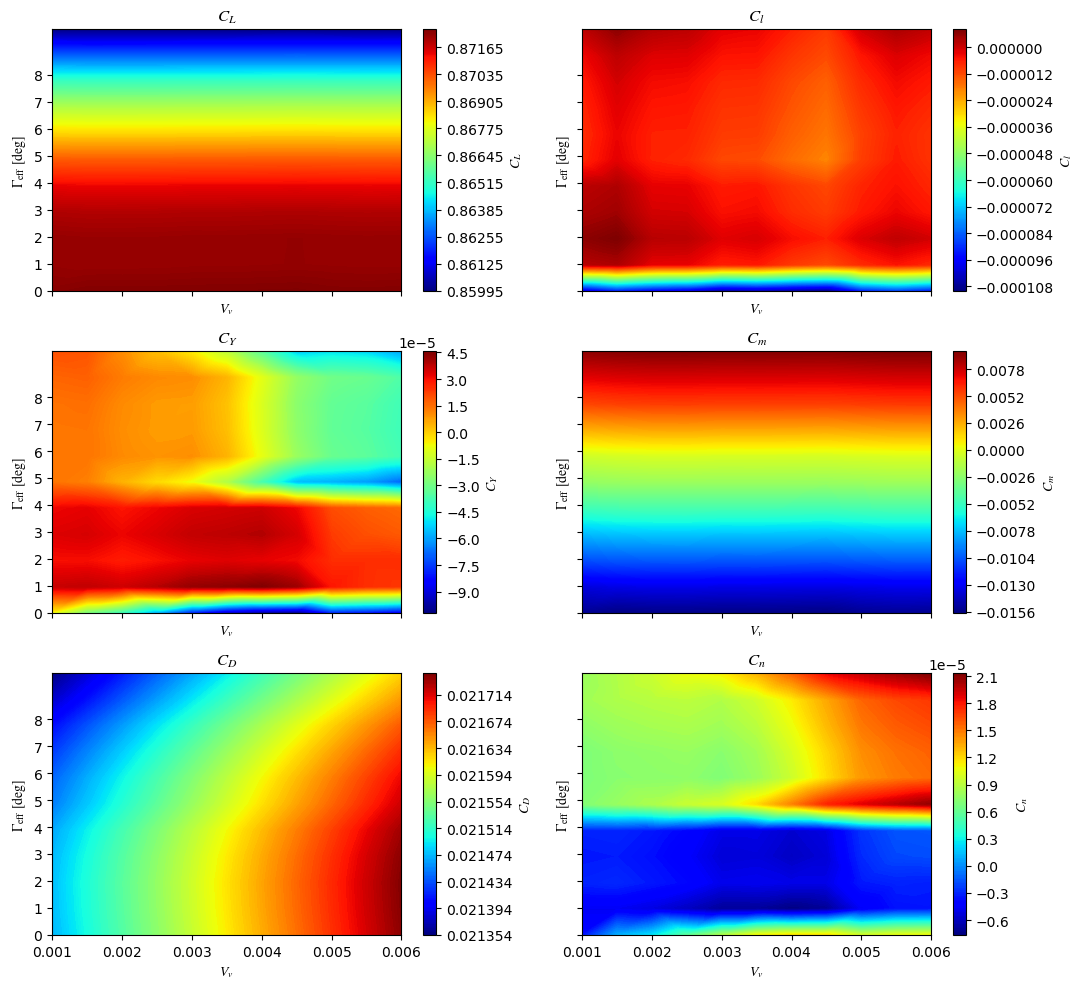

In [9]:
base_panels = [
    ("CL_Base", r"$C_L$"),
    ("CMl_Base", r"$C_l$"),
    ("CY_Base", r"$C_Y$"),
    ("CMm_Base", r"$C_m$"),
    ("CD_Base", r"$C_D$"),
    ("CMn_Base", r"$C_n$"),
]

fig, axes = plt.subplots(3, 2, figsize=(11, 10), sharex=True, sharey=True)
for ax, (column, label) in zip(axes.flat, base_panels):
    plot_vv_gamma_contour_panel(df, column, ax=ax, label=label, **PANEL_KWARGS)

save_figure(fig, "vv_gamma_base_coefficients")
plt.show()

## 6. 縦の空力微係数

列は左から $C_L, C_D, C_m$、行は上から $\alpha, \beta, \hat p, \hat q, \hat r, \delta_e, \delta_a, \delta_r$ とする。

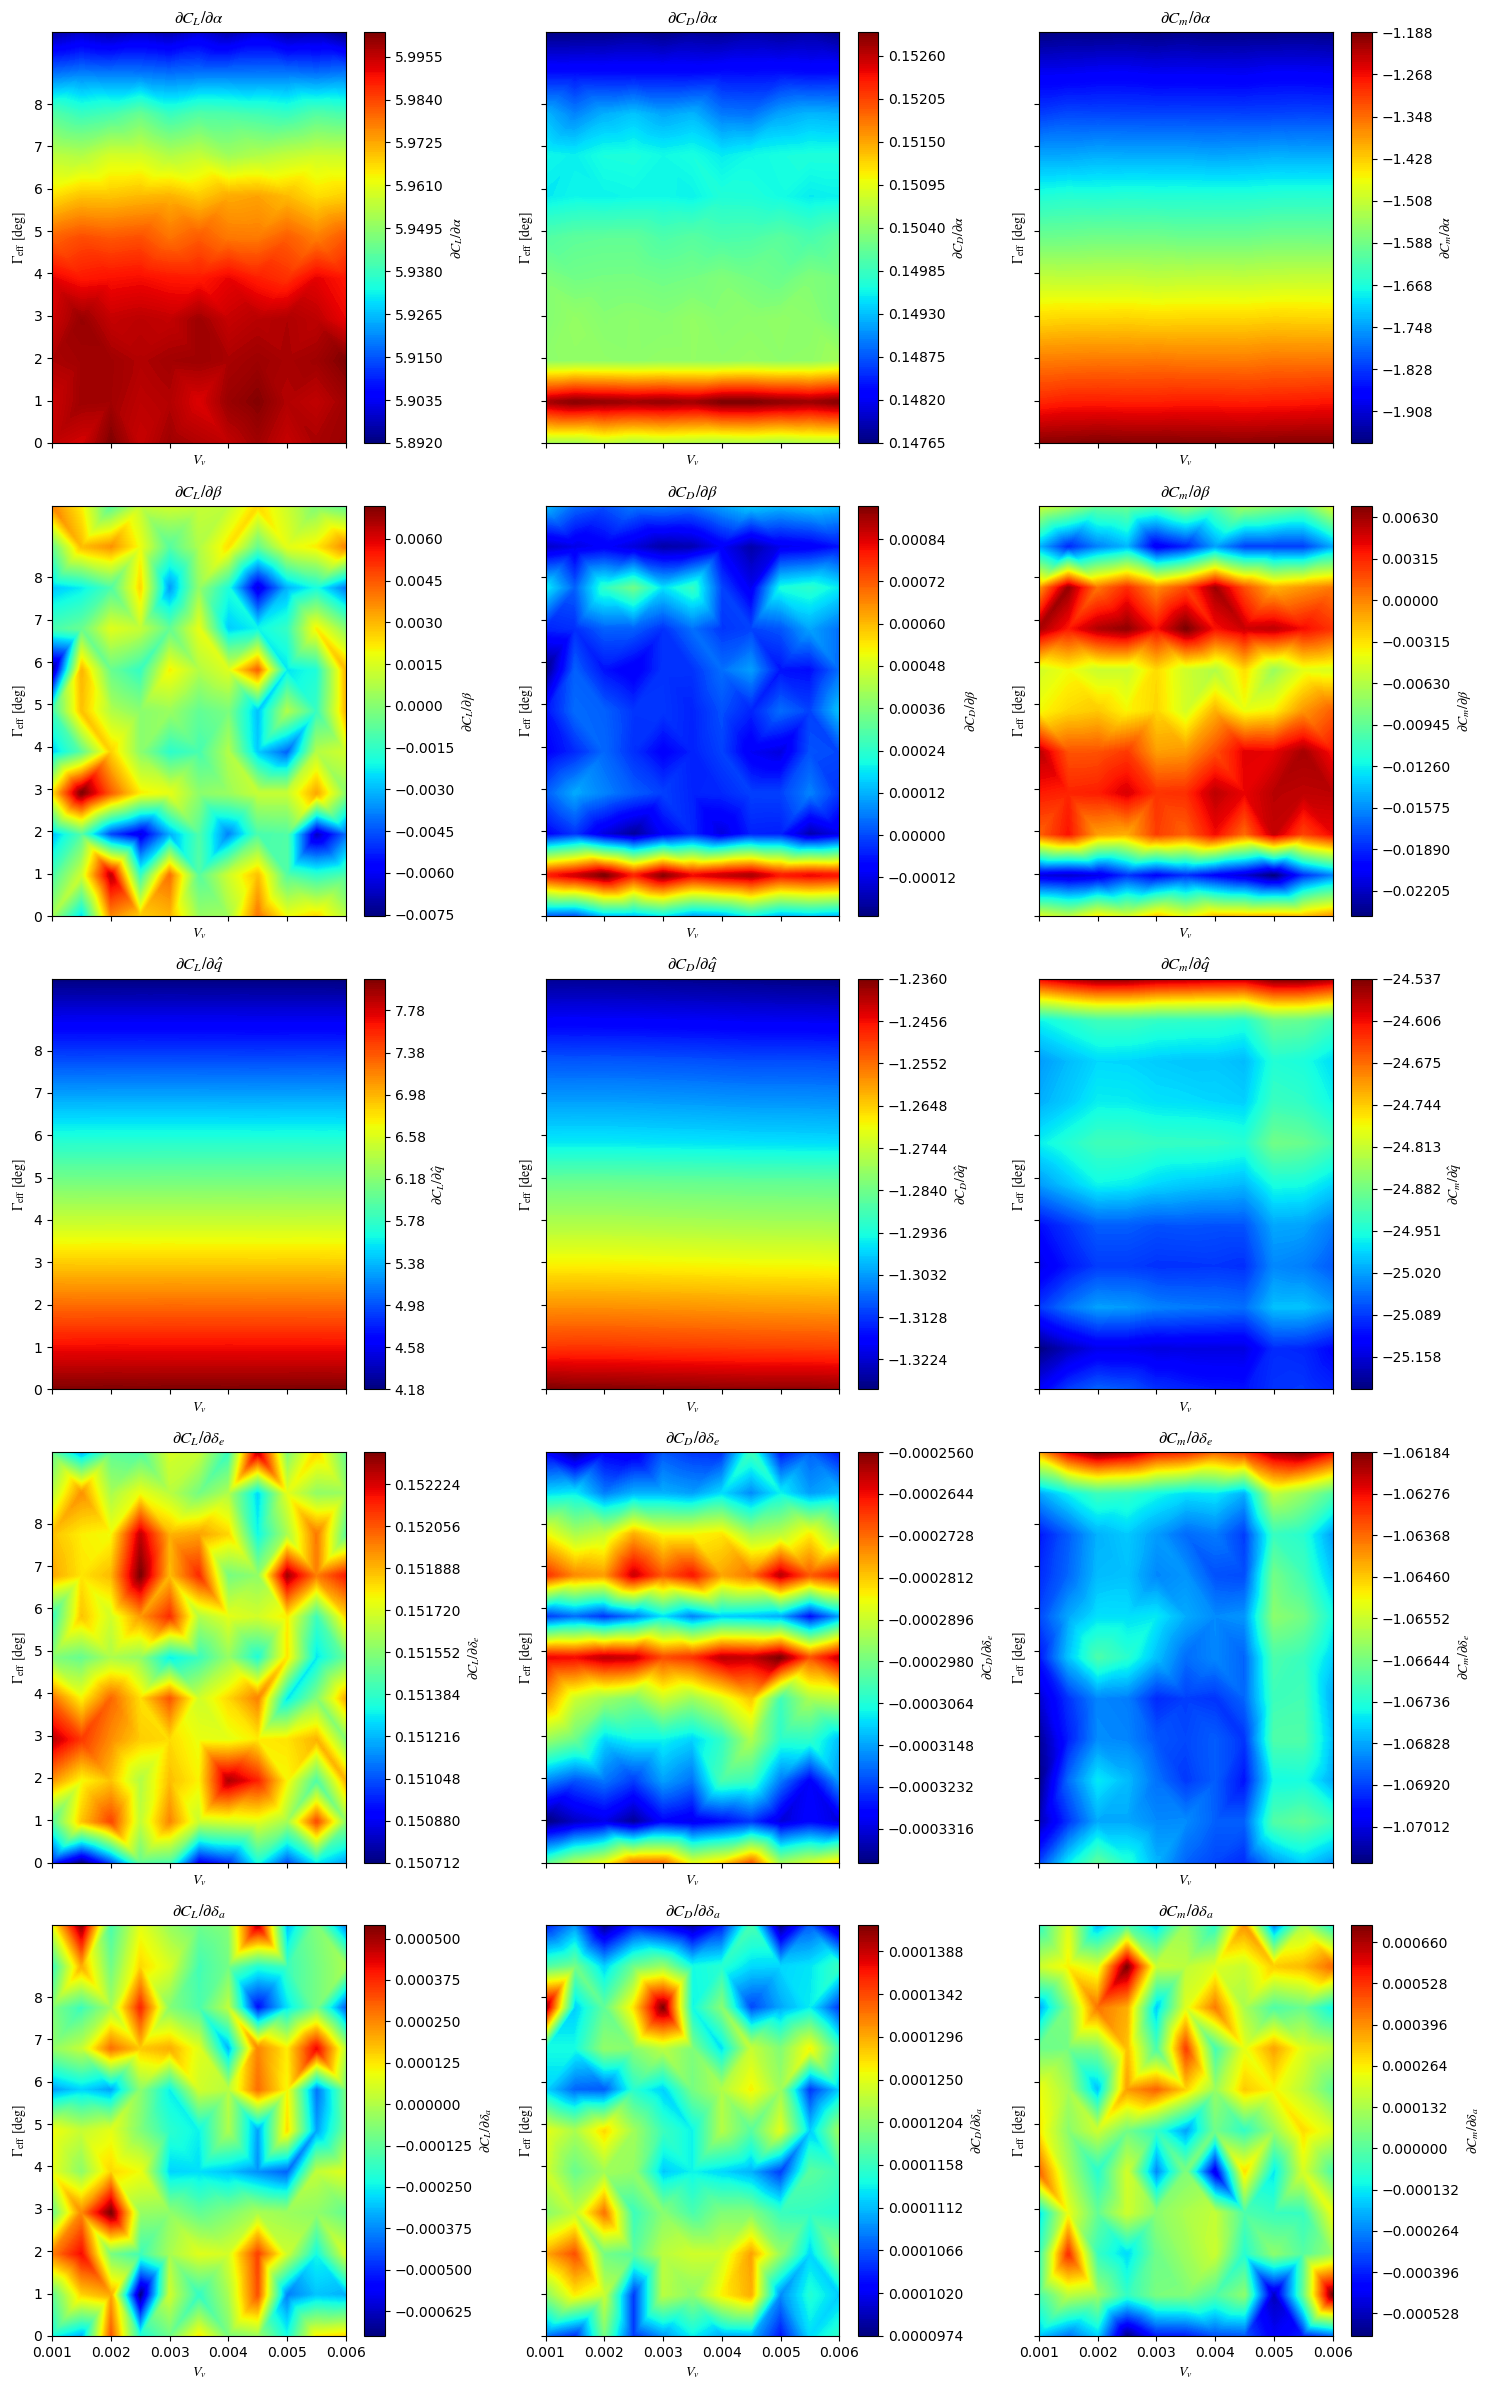

In [10]:
derivative_rows = [
    ("Alpha", r"\alpha"),
    ("Beta", r"\beta"),
    # ("p", r"\hat{p}"),
    ("q", r"\hat{q}"),
    # ("r", r"\hat{r}"),
    (delta_to_congrp["delta_e"], r"\delta_e"),
    (delta_to_congrp["delta_a"], r"\delta_a"),
    # (delta_to_congrp["delta_r"], r"\delta_r"),
]

longitudinal_columns = [
    ("CL", r"C_L"),
    ("CD", r"C_D"),
    ("CMm", r"C_m"),
]

fig, axes = plt.subplots(len(derivative_rows), len(longitudinal_columns), figsize=(15, 24), sharex=True, sharey=True)

for row_index, (suffix, variable_label) in enumerate(derivative_rows):
    for col_index, (prefix, coefficient_label) in enumerate(longitudinal_columns):
        column = f"{prefix}_{suffix}"
        label = rf"$\partial {coefficient_label}/\partial {variable_label}$"
        plot_vv_gamma_contour_panel(df, column, ax=axes[row_index, col_index], label=label, **PANEL_KWARGS)

save_figure(fig, "vv_gamma_longitudinal_derivatives")
plt.show()

## 7. 横・方向の空力微係数

列は左から $C_Y, C_l, C_n$、行は上から $\alpha, \beta, \hat p, \hat q, \hat r, \delta_e, \delta_a, \delta_r$ とする。

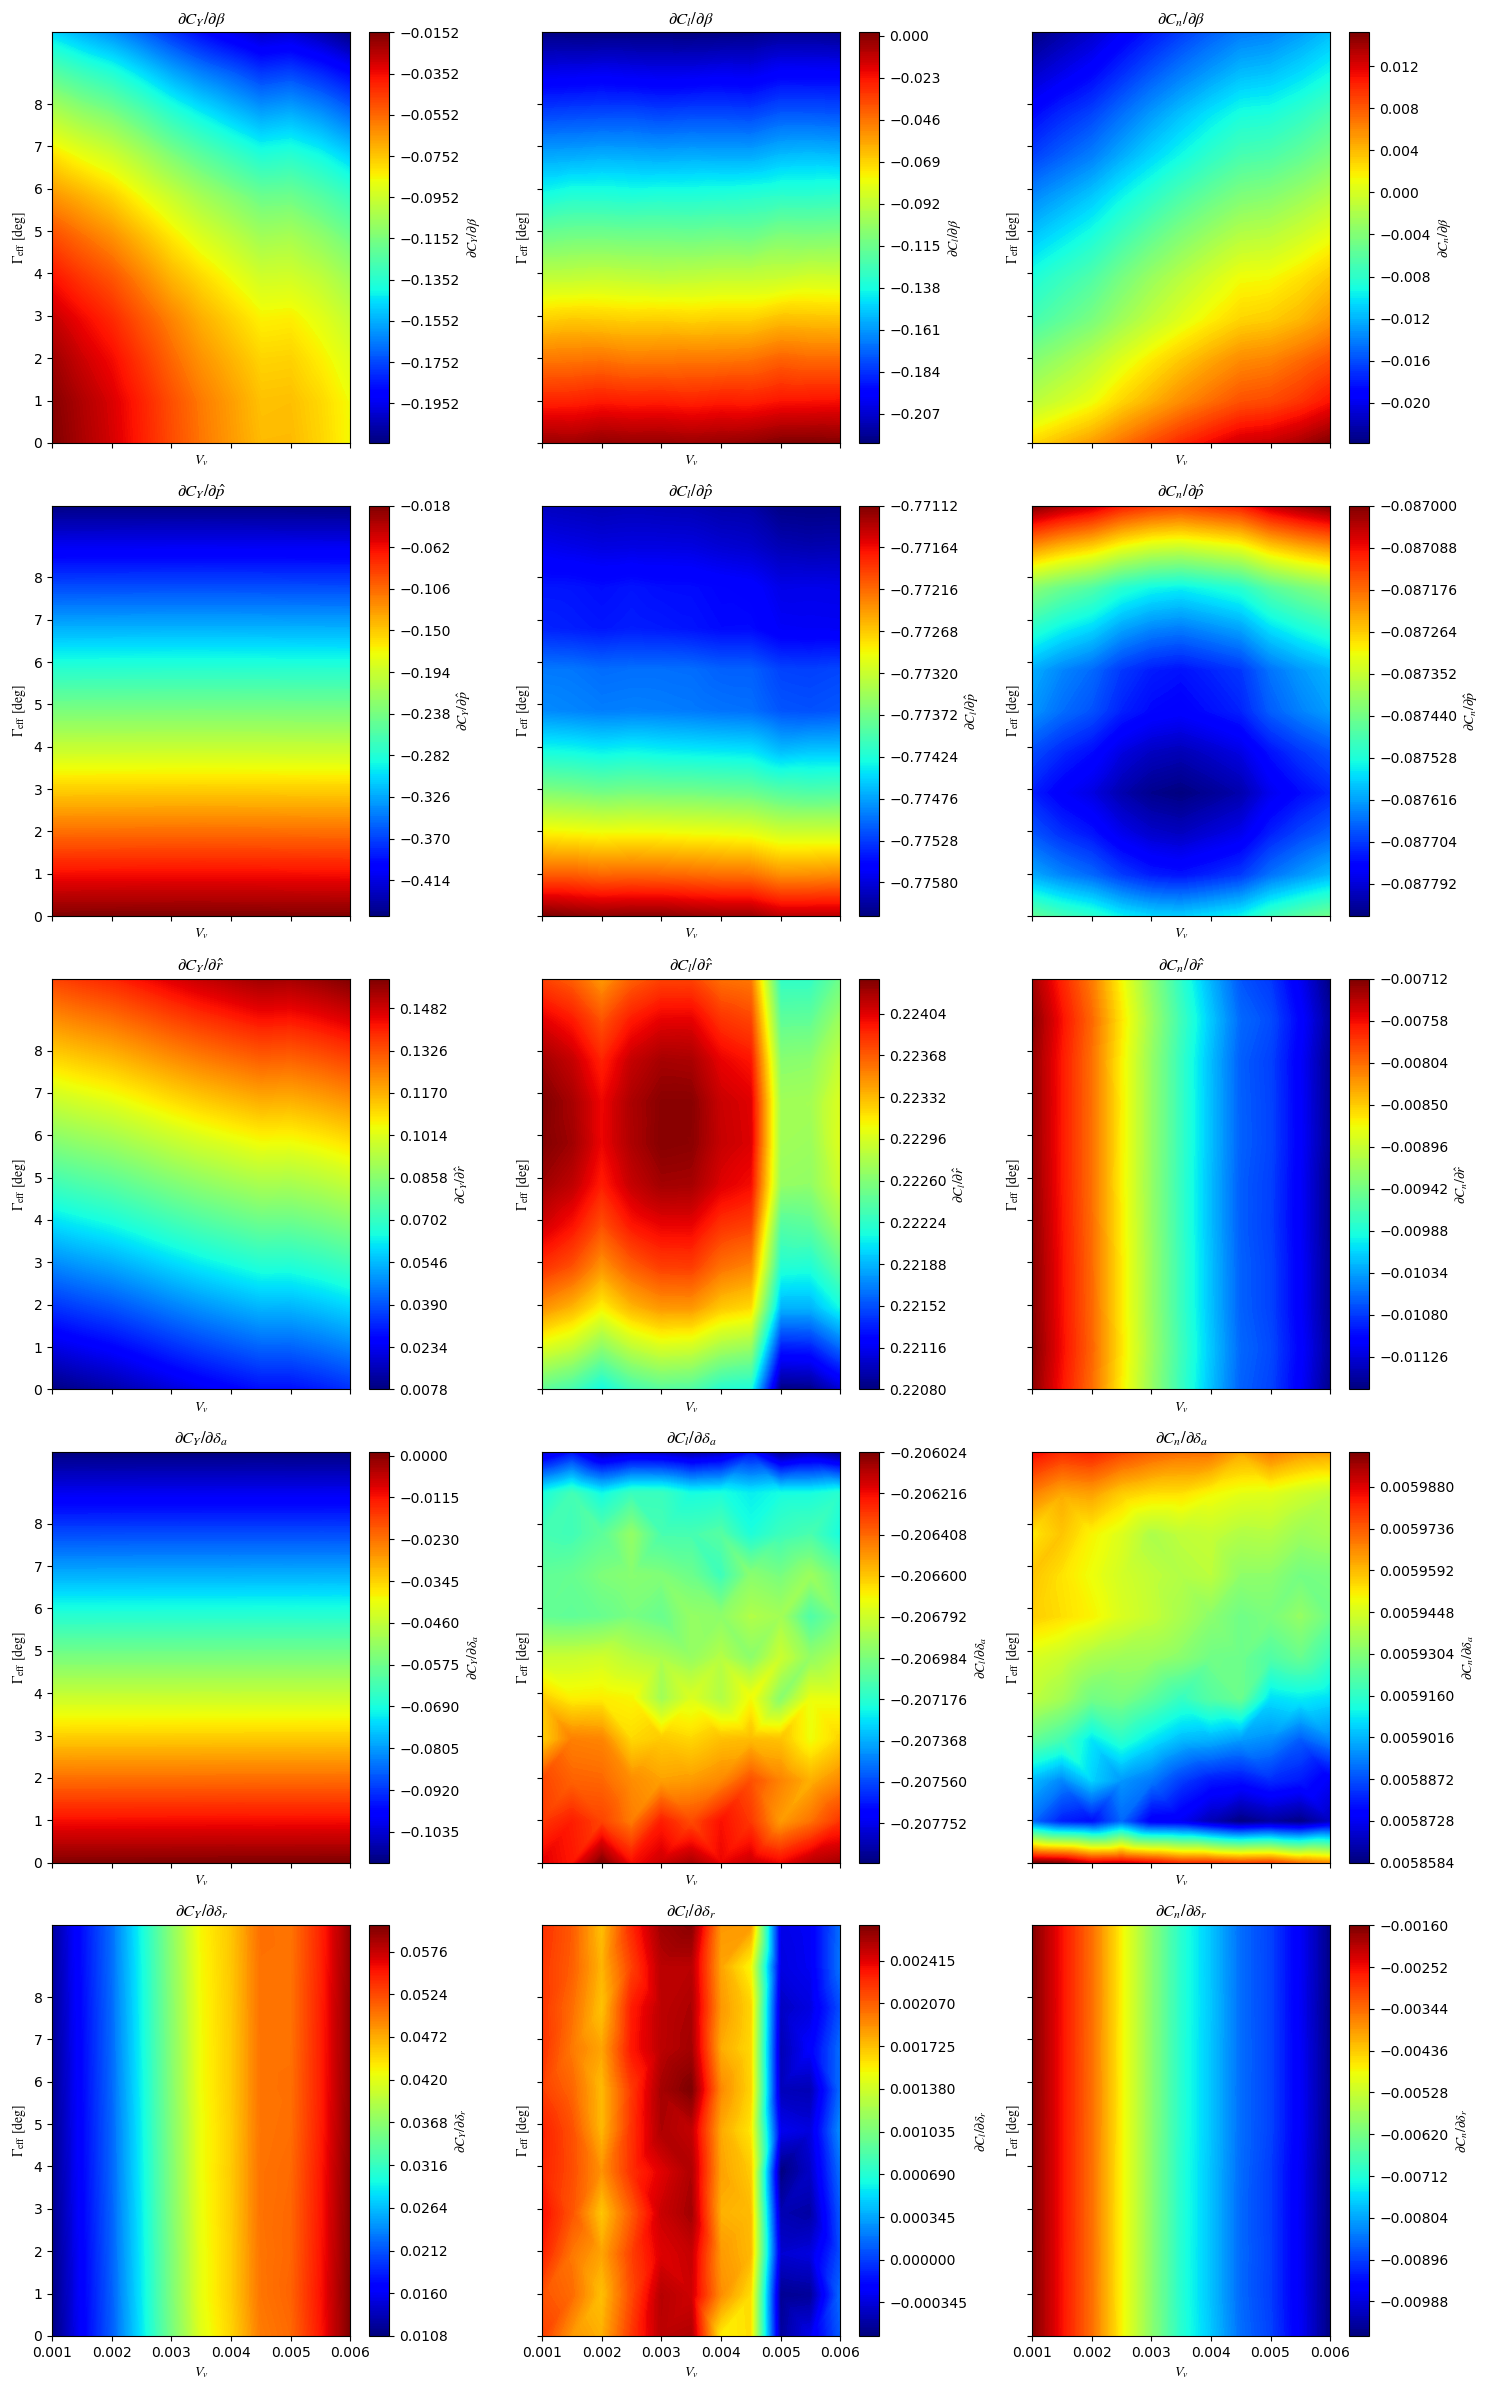

In [11]:
lateral_columns = [
    ("CY", r"C_Y"),
    ("CMl", r"C_l"),
    ("CMn", r"C_n"),
]
derivative_rows = [
    ("Beta", r"\beta"),
    ("p", r"\hat{p}"),
    ("r", r"\hat{r}"),
    (delta_to_congrp["delta_a"], r"\delta_a"),
    (delta_to_congrp["delta_r"], r"\delta_r"),
]

fig, axes = plt.subplots(len(derivative_rows), len(lateral_columns), figsize=(15, 24), sharex=True, sharey=True)

for row_index, (suffix, variable_label) in enumerate(derivative_rows):
    for col_index, (prefix, coefficient_label) in enumerate(lateral_columns):
        column = f"{prefix}_{suffix}"
        label = rf"$\partial {coefficient_label}/\partial {variable_label}$"
        plot_vv_gamma_contour_panel(df, column, ax=axes[row_index, col_index], label=label, **PANEL_KWARGS)

save_figure(fig, "vv_gamma_lateral_derivatives")
plt.show()

## 8. ラダーのみ旋回の評価指標

ラダーのみ旋回でよく見る指標をまとめて描画する。

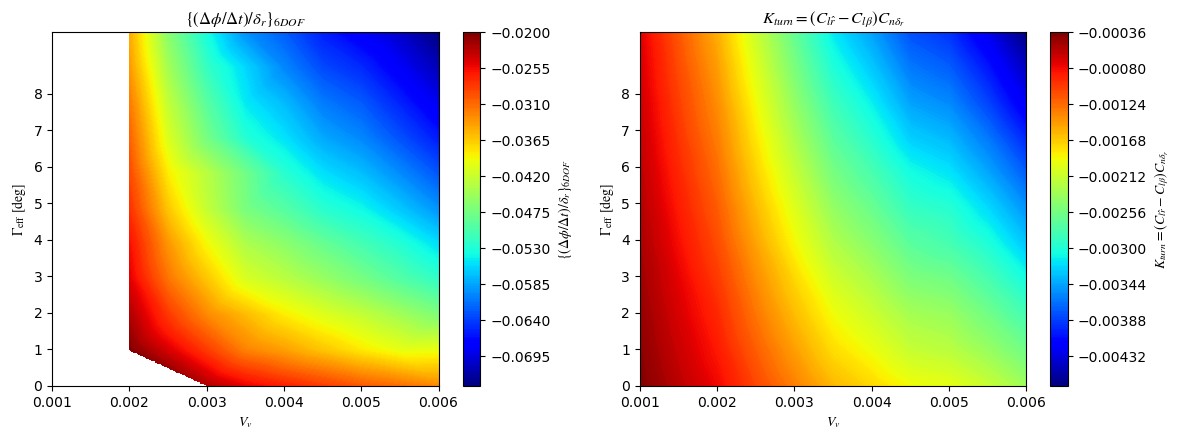

In [12]:

metric_panels = [
    ("sixdof_roll_response_phi_rate_per_delta_r", None),
    ('simple_turn_rate', None),
]

# fig, axes = plt.subplots(1, len(metric_panels), figsize=(4*len(metric_panels), 3), sharex=True, sharey=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 9/2), sharex=False, sharey=False)
for ax, (column, label) in zip(axes.flat, metric_panels):
    plot_vv_gamma_contour_panel(df, column, ax=ax, label=label, **PANEL_KWARGS)

save_figure(fig, "vv_gamma_rudder_turn_metrics")
plt.show()

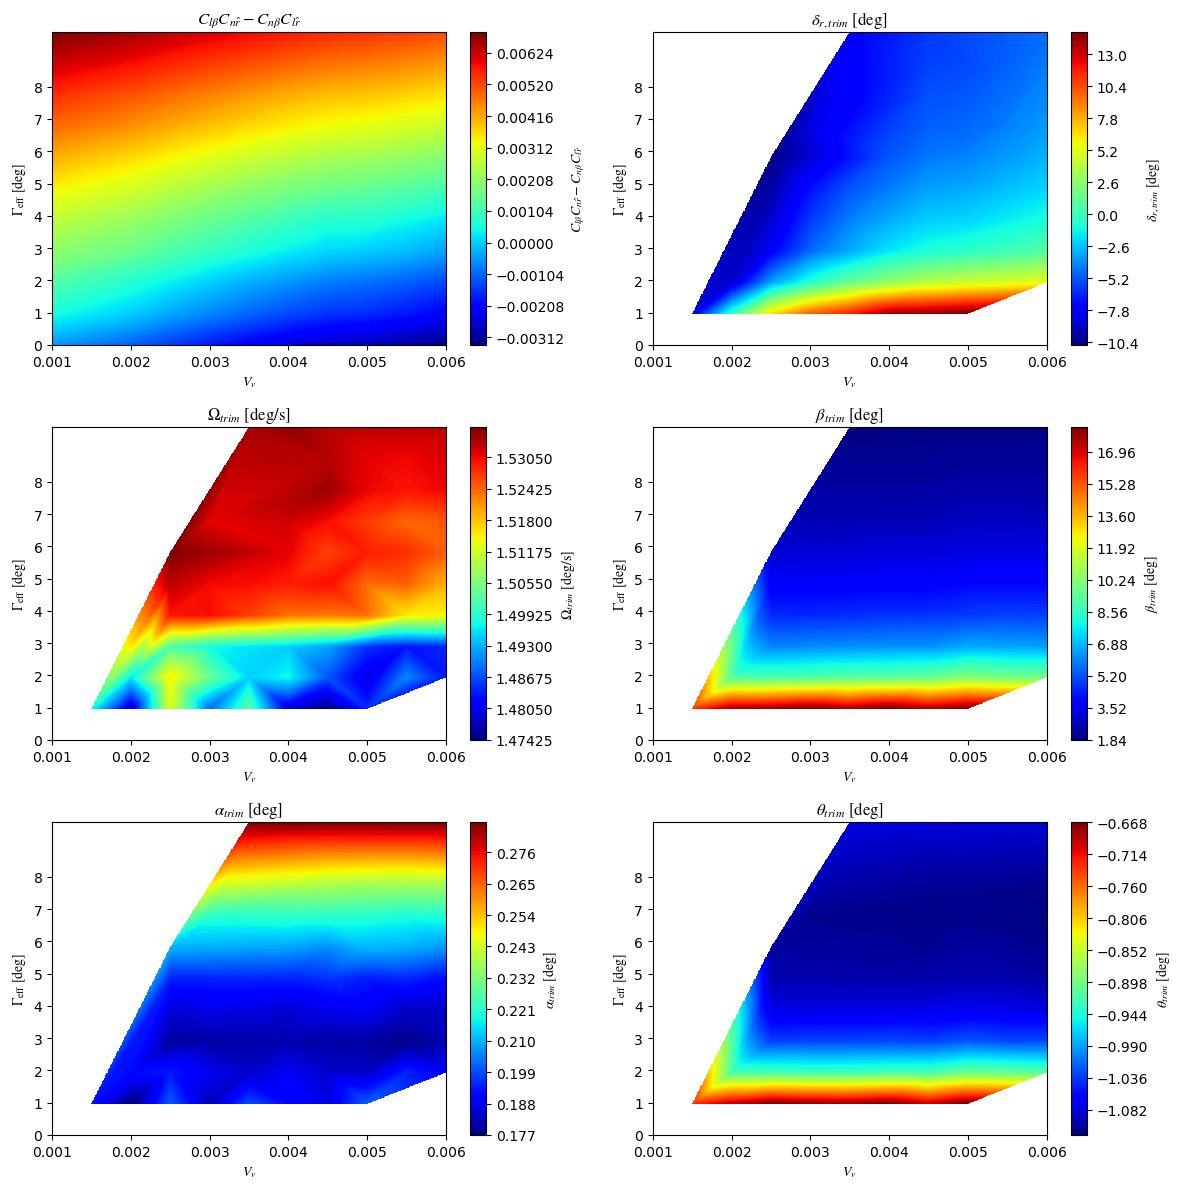

In [13]:

metric_panels = [
  ("spiral_margin", None),
  ("turn_trim_delta_r", None),
  ("turn_trim_Omega", None),
  ("turn_trim_beta", None),
  ("turn_trim_alpha", None),
  ("turn_trim_theta", None),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=False, sharey=False)
for ax, (column, label) in zip(axes.flat, metric_panels):
    plot_vv_gamma_contour_panel(df, column, ax=ax, label=label, **PANEL_KWARGS)

save_figure(fig, "vv_gamma_rudder_turn_metrics")
plt.show()

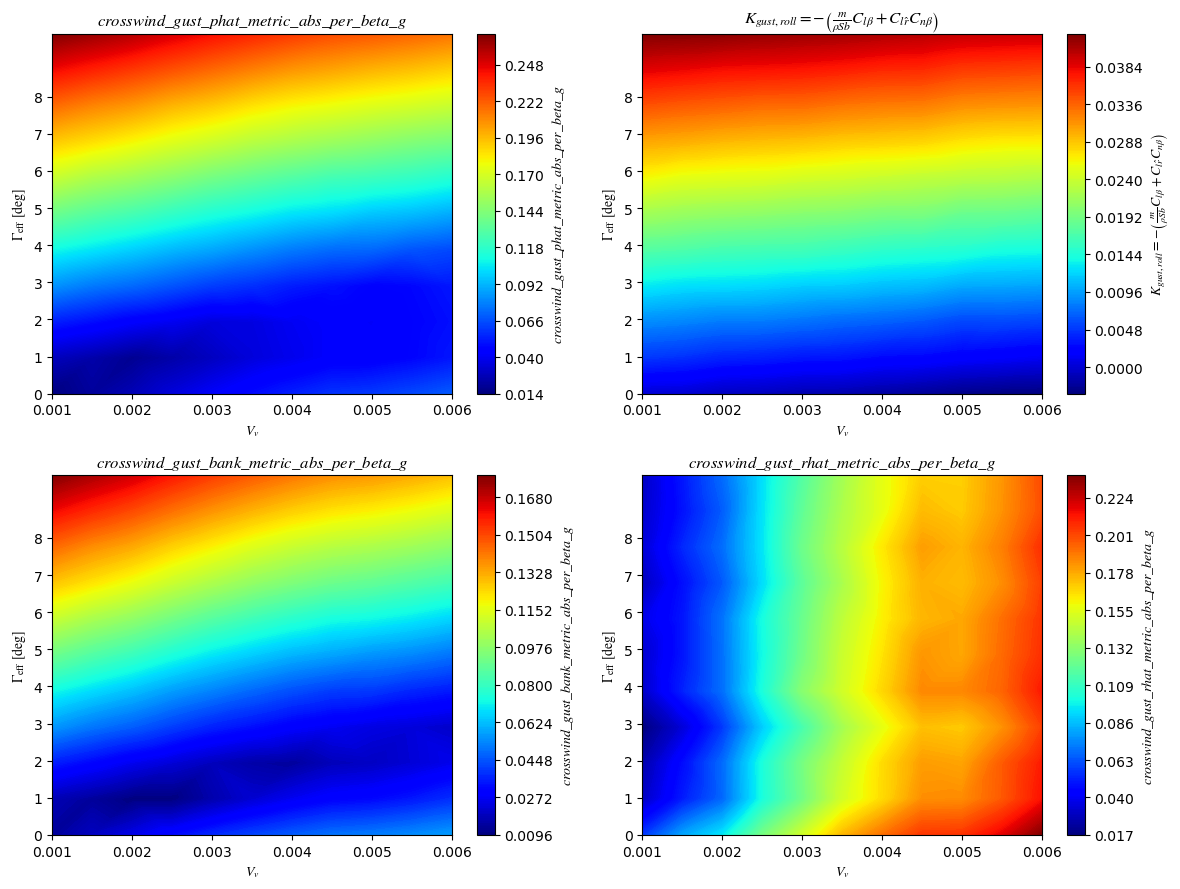

In [18]:

metric_panels = [
  ("crosswind_gust_phat_metric_abs_per_beta_g", None),
  ("crosswind_gust_roll_metric", None),
  ("crosswind_gust_bank_metric_abs_per_beta_g", None),
  ("crosswind_gust_rhat_metric_abs_per_beta_g", None),
]

# df_trim = df[df["turn_trim_passed"] == True].copy()
# fig, axes = plt.subplots(1, len(metric_panels), figsize=(4*len(metric_panels), 3), sharex=True, sharey=True)
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False, sharey=False)
for ax, (column, label) in zip(axes.flat, metric_panels):
    plot_vv_gamma_contour_panel(df, column, ax=ax, label=label, **PANEL_KWARGS)

save_figure(fig, "vv_gamma_rudder_turn_metrics")
plt.show()

## 9. 出力ファイル

生成した図は `vv_gamma_chart_plots/` に保存される。

In [15]:
for path in sorted(output_dir.glob("vv_gamma_*")):
    print(path)

vv_gamma_chart_plots\vv_gamma_base_coefficients.pdf
vv_gamma_chart_plots\vv_gamma_base_coefficients.png
vv_gamma_chart_plots\vv_gamma_lateral_derivatives.pdf
vv_gamma_chart_plots\vv_gamma_lateral_derivatives.png
vv_gamma_chart_plots\vv_gamma_longitudinal_derivatives.pdf
vv_gamma_chart_plots\vv_gamma_longitudinal_derivatives.png
vv_gamma_chart_plots\vv_gamma_rudder_turn_metrics.pdf
vv_gamma_chart_plots\vv_gamma_rudder_turn_metrics.png


## 横転6DOF

In [16]:

# from src.RollRudderGain import (
#     plot_vv_gamma_row_6dof_vs_reduced_response,
# )

# plot_vv_gamma_row_6dof_vs_reduced_response(
#     metrics=Path(f"vv_gamma_metrics.csv"),
#     row_index=120,
#     mass=mass,
#     inertia=inertia,
#     rho=None,
#     control_map=None,
#     history_path_column="sixdof_history_csv_path",
#     recompute_6dof_if_missing=True,
#     plot_path=None,
#     show=True,
#     degrees=True,
#     max_step=0.01,
#     rtol=1.0e-8,
#     atol=1.0e-10,
#     include_roll_damping=False,
#     include_yaw_damping=False,
# )

In [17]:

# from src.RollRudderGain import (
#     plot_vv_gamma_row_6dof_vs_reduced_response,
# )

# plot_vv_gamma_row_6dof_vs_reduced_response(
#     metrics=Path(f"vv_gamma_metrics.csv"),
#     row_index=120,
#     mass=mass,
#     inertia=inertia,
#     rho=None,
#     control_map=None,
#     history_path_column="sixdof_history_csv_path",
#     recompute_6dof_if_missing=True,
#     plot_path=None,
#     show=True,
#     degrees=True,
#     max_step=0.01,
#     rtol=1.0e-8,
#     atol=1.0e-10,
#     include_roll_damping=True,
#     include_yaw_damping=True,
# )